In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
path = "../data_pcb_smu/2026-02-25 new-wafer-1 device characterization/w1_c3_dirac_drift.csv"

# Channels to include (0-based index after the time column)
channels_to_plot = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15]

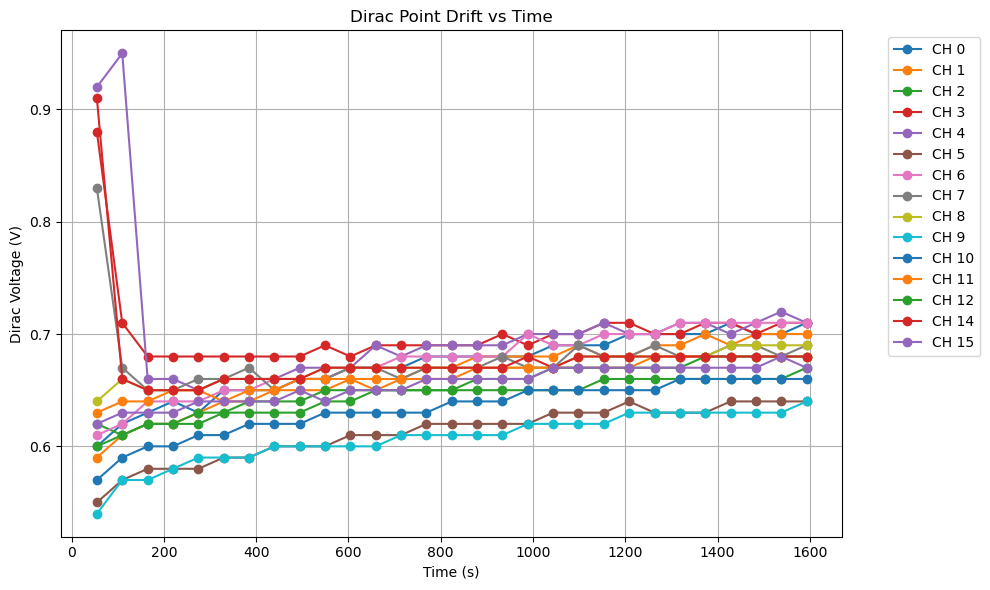

In [3]:
# Load the data (adjust filename)
df = pd.read_csv(path)

# Identify rows that contain Dirac data (DIRAC_SWEEP_IDX is not NaN)
dirac_rows = df[df["DIRAC_SWEEP_IDX"].notna()].copy()

# Use time from previous row (n-1)
dirac_rows["TIME_FROM_PREV"] = df["TIME"].shift(1).loc[dirac_rows.index].values

# Collect Dirac voltages for all 16 channels
channel_cols_to_get = [f"DIRAC_V_FWD_CH{i}" for i in range(16)]

# Plot
plt.figure(figsize=(10, 6))

for ch in channels_to_plot:
    plt.plot(dirac_rows["TIME_FROM_PREV"], dirac_rows[channel_cols_to_get[ch]], marker="o", label=f"CH {ch}")

plt.xlabel("Time (s)")
plt.ylabel("Dirac Voltage (V)")
plt.title("Dirac Point Drift vs Time")
# plt.legend(ncol=2, fontsize=9, loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()

In [4]:
percent_drifts = []

for ch in channels_to_plot:
    col = channel_cols_to_get[ch]
    values = dirac_rows[col].dropna().values

    if len(values) < 4:
        print(f"CH {ch}: not enough Dirac points ({len(values)})")
        continue

    v_4th = values[3]      # 4th Dirac point (0-based indexing)
    v_last = values[-1]   # last Dirac point

    percent_drift = 100 * (v_last - v_4th) / v_4th
    percent_drifts.append(percent_drift)

    print(f"CH {ch}: {percent_drift:.3f} % drift")

percent_drifts = np.array(percent_drifts)

print("\nSummary for selected channels:")
print(f"Mean drift: {percent_drifts.mean():.3f} %")
print(f"Std dev:    {percent_drifts.std(ddof=1):.3f} %")

CH 0: 10.937 % drift
CH 1: 12.903 % drift
CH 2: 8.065 % drift
CH 3: 4.412 % drift
CH 4: 7.576 % drift
CH 5: 10.345 % drift
CH 6: 10.937 % drift
CH 7: 6.154 % drift
CH 8: 6.154 % drift
CH 9: 10.345 % drift
CH 10: 10.000 % drift
CH 11: 4.615 % drift
CH 12: 9.677 % drift
CH 14: 4.615 % drift
CH 15: 6.349 % drift

Summary for selected channels:
Mean drift: 8.206 %
Std dev:    2.725 %


Last Dirac sweep index: 28


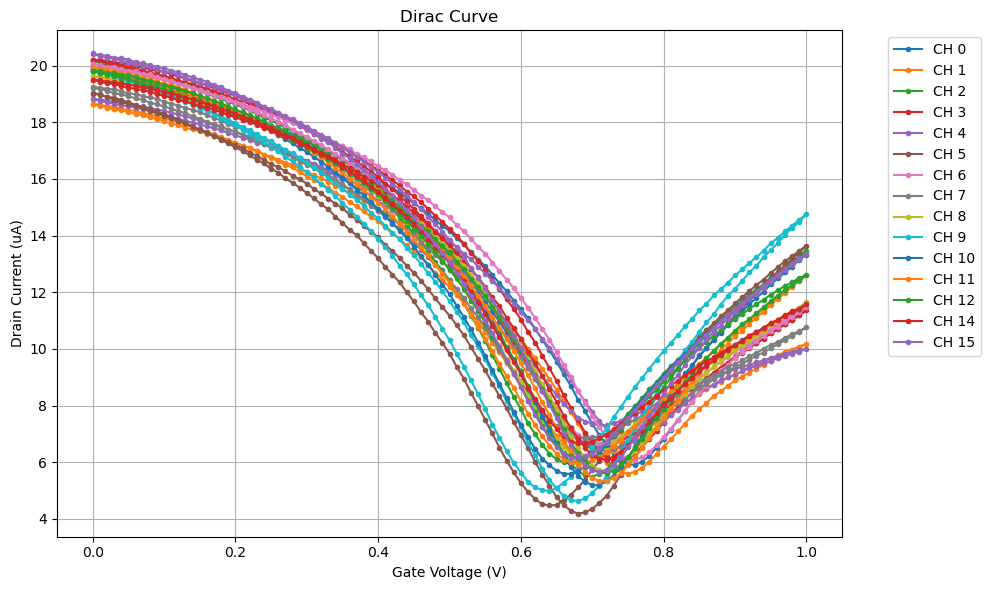

In [5]:
# 1) Find the last Dirac entry
last_dirac_row = df[df["DIRAC_SWEEP_IDX"].notna()].iloc[-1]
last_sweep_idx = int(last_dirac_row["DIRAC_SWEEP_IDX"])

print("Last Dirac sweep index:", last_sweep_idx)

# 2) Extract that sweep's forward curve
last_sweep_df = df[df["SWEEP_IDX"] == last_sweep_idx].copy()

# If you have both forward and reverse in same sweep, 
# and POINT resets, this assumes forward is the first half:
# (adjust if your acquisition tags forward/reverse differently)
forward_df = last_sweep_df.sort_values("POINT")

# 3) Plot I vs V for selected channels
plt.figure(figsize=(10, 6))

for ch in channels_to_plot:
    plt.plot(
        forward_df["V_GATE"],
        forward_df[f"I_CH{ch}"] * 1e6,
        marker=".",
        label=f"CH {ch}"
    )

plt.xlabel("Gate Voltage (V)")
plt.ylabel("Drain Current (uA)")
plt.title("Dirac Curve")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()